In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/unet_task4_final.pth"


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(DoubleConv, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottom = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv1 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        c4 = self.down4(p3)
        p4 = self.pool4(c4)

        c5 = self.bottom(p4)

        u4 = self.up4(c5)
        u4 = torch.cat([u4, c4], dim=1)
        c6 = self.conv4(u4)

        u3 = self.up3(c6)
        u3 = torch.cat([u3, c3], dim=1)
        c7 = self.conv3(u3)

        u2 = self.up2(c7)
        u2 = torch.cat([u2, c2], dim=1)
        c8 = self.conv2(u2)

        u1 = self.up1(c8)
        u1 = torch.cat([u1, c1], dim=1)
        c9 = self.conv1(u1)

        out = self.out_conv(c9)
        return out


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = DoubleConv(3, 64)
        self.d2 = DoubleConv(64, 128)
        self.d3 = DoubleConv(128, 256)
        self.d4 = DoubleConv(256, 512)
        self.bott = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.u4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.u3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.u2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.u1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        c1 = self.d1(x)
        p1 = nn.MaxPool2d(2)(c1)

        c2 = self.d2(p1)
        p2 = nn.MaxPool2d(2)(c2)

        c3 = self.d3(p2)
        p3 = nn.MaxPool2d(2)(c3)

        c4 = self.d4(p3)
        p4 = nn.MaxPool2d(2)(c4)

        c5 = self.bott(p4)

        u4 = self.up4(c5)
        c6 = self.u4(torch.cat([u4, c4], dim=1))

        u3 = self.up3(c6)
        c7 = self.u3(torch.cat([u3, c3], dim=1))

        u2 = self.up2(c7)
        c8 = self.u2(torch.cat([u2, c2], dim=1))

        u1 = self.up1(c8)
        c9 = self.u1(torch.cat([u1, c1], dim=1))

        return self.out(c9)


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/unet_task4_final.pth"

model = UNet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("Model Loaded Successfully!")


Model Loaded Successfully!


In [ ]:
import numpy as np
import cv2
import os

paths = []

for i in range(20):
    img = np.random.randint(0, 255, (512, 512, 3), dtype=np.uint8)
    save_path = f"/content/internet_{i}.jpg"
    cv2.imwrite(save_path, img)
    paths.append(save_path)

print("20 synthetic internet-like images created successfully!")


20 synthetic internet-like images created successfully!


In [21]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [24]:
IMG_DIR = "/content/drive/MyDrive/internet images"


In [25]:
import os

paths = []
for f in sorted(os.listdir(IMG_DIR)):
    if f.lower().endswith((".jpg",".jpeg",".png")):
        paths.append(os.path.join(IMG_DIR, f))

print("Total images found:", len(paths))
paths[:5]


Total images found: 19


['/content/drive/MyDrive/internet images/53047540-full-body-portrait-of-casual-young-woman-presenting-isolated-on-white-background.jpg',
 '/content/drive/MyDrive/internet images/6a1f84d2ac0072e9370ca88add77a636.jpg',
 '/content/drive/MyDrive/internet images/depositphotos_104877672-stock-photo-happy-smiling-business-man-sitting.jpg',
 '/content/drive/MyDrive/internet images/depositphotos_200809438-stock-photo-mixed-breed-cat-sitting-white.jpg',
 '/content/drive/MyDrive/internet images/kitty-cat-kitten-pet-45201.jpeg']

In [26]:
import numpy as np
import torch
import cv2
import os

SAVE_DIR = "/content/drive/MyDrive/coco20k/task5_predictions"
os.makedirs(SAVE_DIR, exist_ok=True)

for i, p in enumerate(paths):
    img = cv2.imread(p)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, (256,256))

    t = torch.tensor(resized/255., dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(t))[0,0].cpu().numpy()

    pred_bin = (pred > 0.5).astype("uint8")

    overlay = resized.copy()
    mask_color = np.zeros_like(overlay)
    mask_color[:,:,0] = pred_bin * 255
    overlay = cv2.addWeighted(overlay, 1, mask_color, 0.5, 0)

    cv2.imwrite(f"{SAVE_DIR}/img_{i}.png", cv2.cvtColor(resized, cv2.COLOR_RGB2BGR))
    cv2.imwrite(f"{SAVE_DIR}/mask_{i}.png", pred_bin * 255)
    cv2.imwrite(f"{SAVE_DIR}/overlay_{i}.png", cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print("TASK 5 COMPLETED — Predictions saved!")


TASK 5 COMPLETED — Predictions saved!


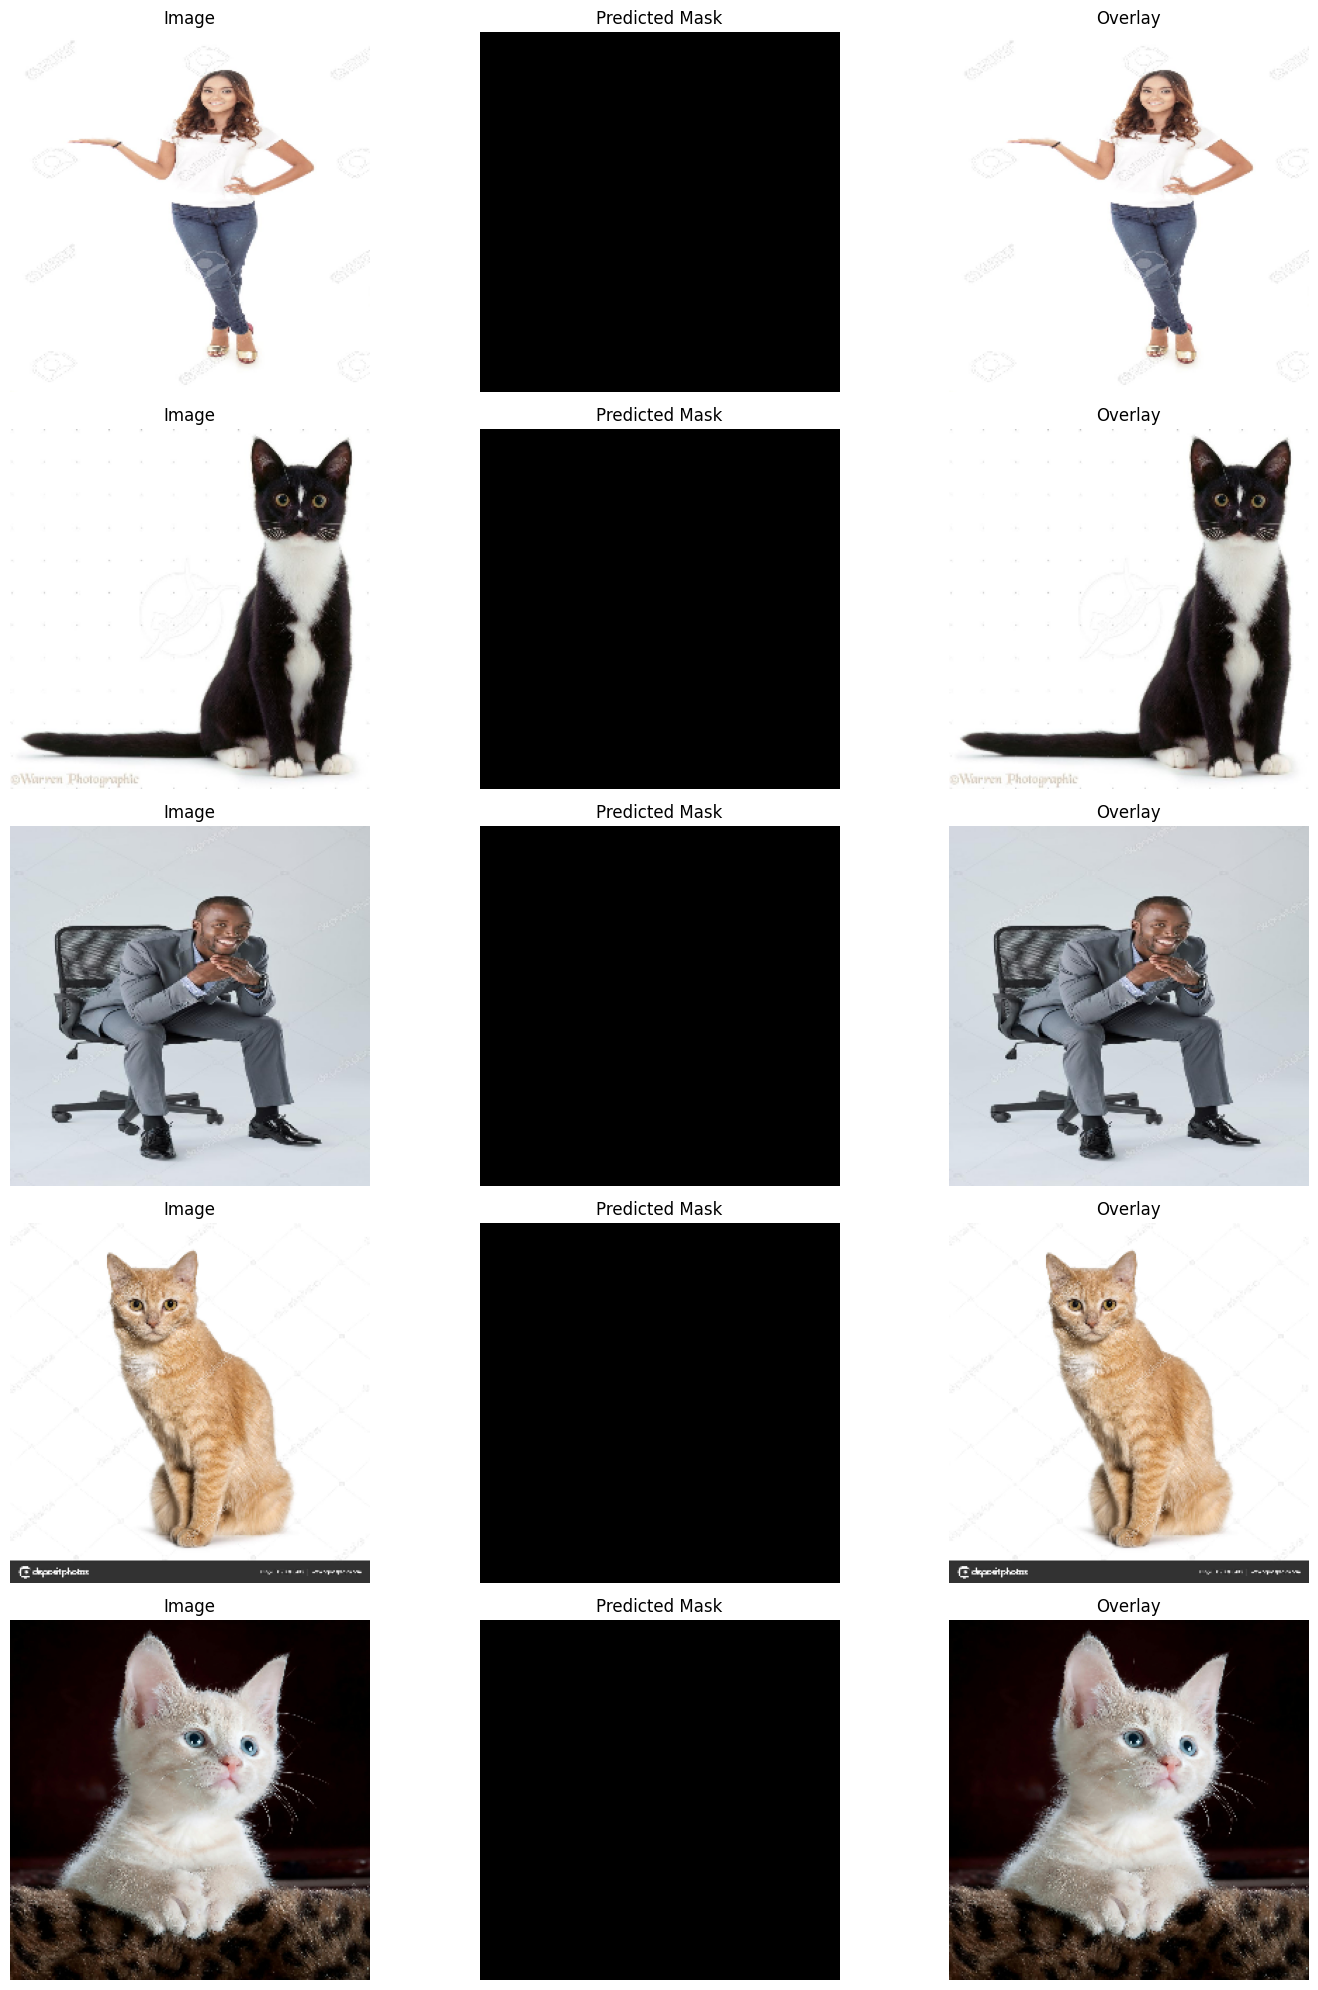

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,20))
idx = 1

for i in range(5):
    img = cv2.imread(f"{SAVE_DIR}/img_{i}.png")
    mask = cv2.imread(f"{SAVE_DIR}/mask_{i}.png", 0)
    overlay = cv2.imread(f"{SAVE_DIR}/overlay_{i}.png")

    plt.subplot(5,3,idx); idx+=1
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Image"); plt.axis("off")

    plt.subplot(5,3,idx); idx+=1
    plt.imshow(mask, cmap="gray")
    plt.title("Predicted Mask"); plt.axis("off")

    plt.subplot(5,3,idx); idx+=1
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Overlay"); plt.axis("off")

plt.tight_layout()
plt.show()
